# Customer Sentiment Analysis of McDonald’s Locations in the U.S.

### Project Overview
Analyzed over 25,000 Google reviews of McDonald's locations across the U.S. to understand what drives customer dissatisfaction and how location, volume, and themes impact service quality



## Business Questions

Where are customers most unhappy?

What common complaints appear repeatedly?

Are high-volume stores still struggling with sentiment?”

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import requests
import time
import pandas as pd

pd.set_option('display.max_colwidth', None)

In [2]:
df_combined = pd.read_csv('df_combined.csv', encoding='latin1')

In [3]:
import re

def preprocess_text(df, column_name):
    
    # Removes special characters & punctuation
    df[column_name] = df[column_name].apply(lambda x: re.sub(r'[^A-Za-z0-9]+', ' ', x))

    # Removes newlines, ensures the text is in a single line
    df[column_name] = df[column_name].apply(lambda x: re.sub(r"\n", " ", x))

    # Removes short words (1-2 characters) to eliminate meaningless words
    df[column_name] = df[column_name].apply(lambda x: re.sub(r'\b[a-zA-Z]{1,2}\b', '', x))

    return df

In [4]:
df_combined = preprocess_text(df_combined, 'review')

In [5]:
import re

def extract_state(address):
    match = re.search(r',\s*([A-Z]{2})\s+\d{5}', address)
    if match:
        return match.group(1)
    return None

df_combined['state'] = df_combined['store_address'].apply(extract_state)


## Exploratory Data Analysis & Visual Insights

### a. Geographic Patterns

Heatmap of negative sentiment across the U.S.

Cluster map to visualize high-volume complaint zones

In [ ]:
import folium
from folium.plugins import HeatMap

# Filter negative sentiment reviews
neg_df = df_combined[df_combined['sentiment'] == 'negative']

# Create base map centered on US
m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles="cartodbpositron")

# Prepare heatmap data
heat_data = neg_df[['latitude', 'longitude']].dropna().values.tolist()

# Add heatmap layer to the map
HeatMap(heat_data, radius=8).add_to(m)

# Show the map in notebook
m

In [ ]:
from folium.plugins import MarkerCluster

map_cluster = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='cartodbpositron')
marker_cluster = MarkerCluster().add_to(map_cluster)

for _, row in df_combined.iterrows():
    color = 'green' if row['sentiment'] == 'positive' else 'red'
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"{row['store_address']}<br>{row['review'][:200]}...",
        icon=folium.Icon(color=color)
    ).add_to(marker_cluster)

map_cluster  # Show in notebook

## 5. Machine Learning Techniques
a. Top Bigrams

b. Topic Modeling 

Identified themes: wait times, order accuracy, staff behavior, cleanliness.

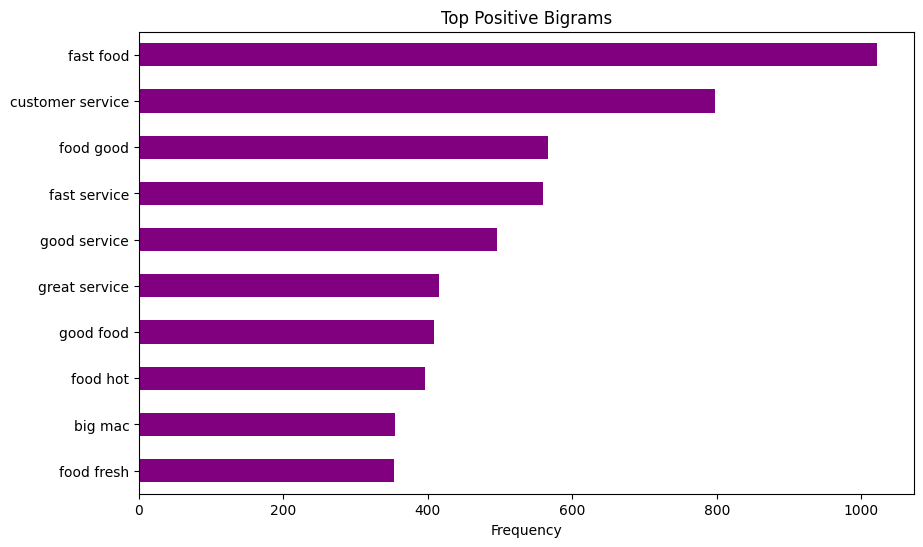

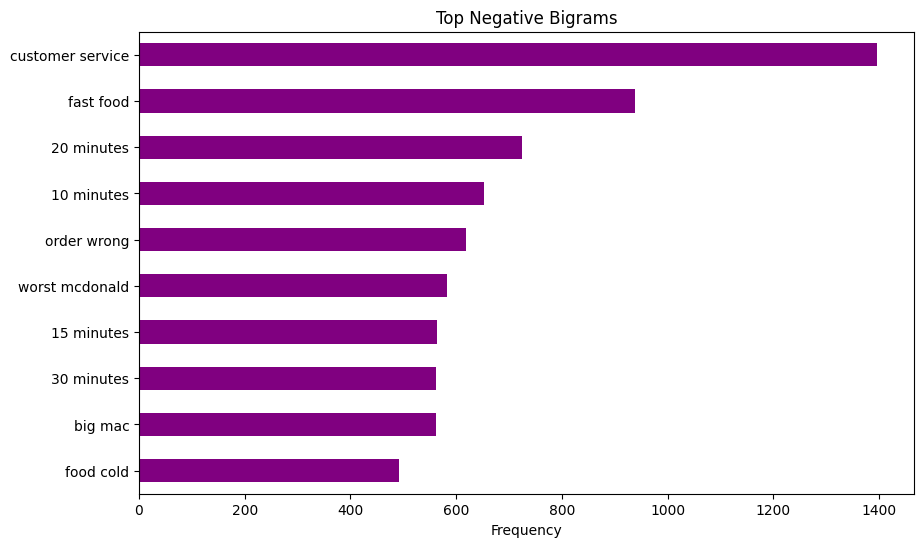

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt


def plot_top_bigrams(text, title, n=10):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=5000)
    X = vec.fit_transform(text.dropna())
    word_counts = pd.Series(X.toarray().sum(axis=0), index=vec.get_feature_names_out()).sort_values(ascending=False).head(n)

    word_counts.plot(kind='barh', figsize=(10, 6), color='purple')
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("Frequency")
    plt.show()

plot_top_bigrams(df_combined[df_combined['sentiment'] == 'positive']['review'], "Top Positive Bigrams")
plot_top_bigrams(df_combined[df_combined['sentiment'] == 'negative']['review'], "Top Negative Bigrams")


LDA (Latent Dirichlet Allocation)

Each topic is a cluster of words that frequently occur together.

The algorithm looks at the word patterns and groups them into topics.

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Only negative reviews 
texts = df_combined[df_combined['sentiment'] == 'negative']['review'].dropna()

vectorizer = CountVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=10  
)
X = vectorizer.fit_transform(texts)

lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda.fit(X)

def print_topics(model, vectorizer, top_n=10):
    words = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(model.components_):
        print(f"\nTopic #{idx+1}:")
        print(", ".join([words[i] for i in topic.argsort()[-top_n:][::-1]]))

print_topics(lda, vectorizer)



Topic #1:
food, order, mcdonald, minutes, place, service, drive, time, people, wait

Topic #2:
order, said, drive, window, told, went, just, got, asked, manager

Topic #3:
service, customer, rude, manager, don, coffee, like, bad, order, just

Topic #4:
fries, food, ordered, order, got, cold, time, sandwich, burger, meal



## Topic #1:
## food, order, mcdonald, minutes, place, service, drive, time, people, wait

## Topic #2:
## order, said, drive, window, told, went, just, got, asked, manager

## Topic #3:
## service, customer, rude, manager, don, coffee, like, bad, order, just

## Topic #4:
## fries, food, ordered, order, got, cold, time, sandwich, burger, meal


## Topic 1 Long wait times

Redesign drive-thru workflows in high-delay locations using queue analytics to reduce wait times.

Implement real-time service monitoring at peak hours to quickly identify and address bottlenecks.

## Topic 2 Miscommunication in drive-thru

Standardize drive-thru scripts and training, especially at locations with frequent escalations.

Introduce digital order confirmation screens to reduce miscommunication at the window.

## Topic 3 Rude or unhelpful staff

Launch a customer service retraining program at locations with high sentiment volatility.

## Topic 4 Food quality—especially cold or wrong orders

Add order accuracy checks before handoff at the counter and drive-thru.

Introduce a time tracking system between food prep and delivery to minimize cold food complaints.